In [18]:
import pandas as pd

df = pd.read_csv("spam.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [19]:
df["Category"].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df["Message"], df["Category"], test_size = 0.2, random_state=9)

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

spam_classifier_pipe = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', MultinomialNB())
])

In [22]:
spam_classifier_pipe.fit(X_train, y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()),
                ('classifier', MultinomialNB())])

In [24]:
from sklearn.metrics import classification_report

y_pred = spam_classifier_pipe.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       961
        spam       0.96      0.90      0.93       154

    accuracy                           0.98      1115
   macro avg       0.97      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



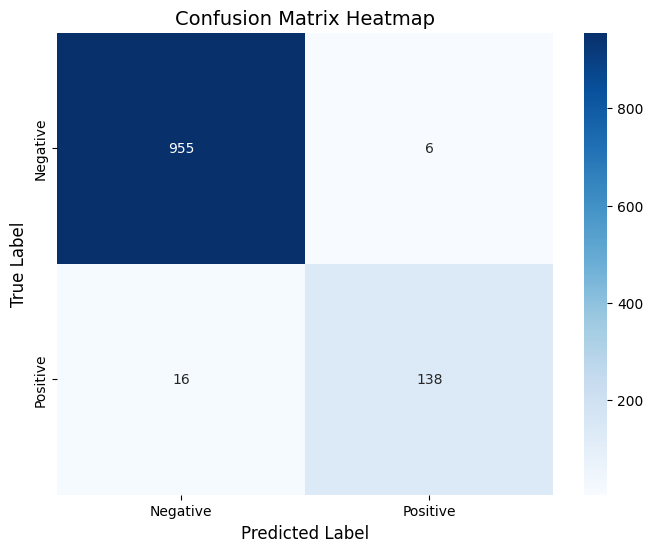

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# --- Sample Confusion Matrix ---
# In your actual code, you would have your confusion matrix stored in the 'cm' variable.
# For demonstration purposes, let's create a sample 2x2 confusion matrix.
# It represents:
# 50 True Positives (Top-Left)
# 10 False Positives (Top-Right)
# 5  False Negatives (Bottom-Left)
# 35 True Negatives (Bottom-Right)

cm = confusion_matrix(y_test, y_pred)

# --- Create the Heatmap ---
# Set the figure size for better readability
plt.figure(figsize=(8, 6))

# Create the heatmap using seaborn
# annot=True: This will write the data value in each cell.
# fmt='d': This ensures the numbers are formatted as integers.
# cmap='Blues': This sets the color map for the heatmap.
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

# --- Add Labels and Title ---
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix Heatmap', fontsize=14)

# --- Display the Plot ---
# This will show the heatmap plot.
plt.show()
